In [34]:
import sys
import torch
import gc
import onnxruntime as ort
from loguru import logger
import json
import shutil

import pandas as pd
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

sys.path.append('/kaggle/input/models/hiimha/emb/pytorch/default/1')
from embeddings.fastEmbed import FastEmbedding
from embeddings.transformer import TransformersEmbedding
from fastembed.common.model_description import PoolingType, ModelSource

### Mapping each pair of context - query into a dict for evaluation metrics ###

In [35]:
class MapTruth:
    def __init__(self, df: pd.DataFrame):
        self.df = df

    def project(self):
        documents = self.df['context'].unique().tolist()
        doc_to_idx = {text: i for i, text in enumerate(documents)}

        queries = self.df['query'].unique().tolist()
        query_to_idx = {text: i for i, text in enumerate(queries)}

        ground_truth = {}
        
        grouped = self.df.groupby('query')['context'].apply(list).to_dict()

        for query_text, context_list in grouped.items():
            q_idx = query_to_idx[query_text]
            # Convert the text contexts into their corresponding document indices
            d_indices = [doc_to_idx[ctx] for ctx in context_list]
            ground_truth[q_idx] = d_indices

        return queries, documents, ground_truth

### Evaluation metrics: ###
* HitRate @k
* Recall @k

In [36]:
def evaluate(models, queries, documents, ground_truth, k_values=[10, 20], embed_batch_size=None):
    results = {}
    for model in models:
        # Determine if the model is a dual encoder
        is_dual_encoder = isinstance(model, TransformersEmbedding)

        if embed_batch_size is None:
            doc_embeddings = np.array(model.encode(documents))
            if is_dual_encoder:
                query_embeddings = np.array(model.encode(queries, is_query=True))
            else:
                query_embeddings = np.array(model.encode(queries))
        else:
            doc_embeddings = np.array(model.encode(documents, batch_size=embed_batch_size))
            if is_dual_encoder:
                query_embeddings = np.array(model.encode(queries, is_query=True, batch_size=embed_batch_size))
            else:
                query_embeddings = np.array(model.encode(queries, batch_size=embed_batch_size))

        # Validate embeddings before computing similarity
        if doc_embeddings.size == 0 or query_embeddings.size == 0:
            raise ValueError(f"Model {model.name} returned empty embeddings.")
        if doc_embeddings.ndim != 2 or query_embeddings.ndim != 2:
            raise ValueError(f"Model {model.name} returned unexpected shape: doc {doc_embeddings.shape}, query {query_embeddings.shape}")

        sim_matrix = cosine_similarity(query_embeddings, doc_embeddings)

        metrics = {}
        for k in k_values:
            metrics[f"Recall@{k}"]  = round(_recall(sim_matrix, ground_truth, k), 4)
            metrics[f"HitRate@{k}"] = round(_hit_rate(sim_matrix, ground_truth, k), 4)

        results[model.name] = metrics
    return results


def _recall(sim_matrix, ground_truth, k):
    scores = [
        sum(1 for i in np.argsort(sim_matrix[q])[::-1][:k] if i in correct) / len(correct)
        for q, correct in ground_truth.items()
    ]
    return np.mean(scores) if scores else 0


def _hit_rate(sim_matrix, ground_truth, k):
    hits = [
        any(i in np.argsort(sim_matrix[q])[::-1][:k] for i in correct)
        for q, correct in ground_truth.items()
    ]
    return np.mean(hits) if hits else 0

### QASPER Dataset Loader

In [37]:
def load_qasper_test() -> pd.DataFrame:
    parquet_url = "https://huggingface.co/datasets/allenai/qasper/resolve/refs%2Fconvert%2Fparquet/qasper/test/0000.parquet"
    
    ds = load_dataset("parquet", data_files={"test": parquet_url}, split="test")
    
    rows = []
    for paper in ds:
        qas_questions = paper["qas"]["question"]
        qas_answers = paper["qas"]["answers"]
        
        for question, answer_set in zip(qas_questions, qas_answers):
            for answer_dict in answer_set["answer"]:
                if answer_dict["unanswerable"]:
                    continue
                
                for evidence in answer_dict["evidence"]:
                    text = evidence.strip()
                    if text and not text.startswith("FLOAT SELECTED"):
                        rows.append({"query": question, "context": text})
                        
    df = (
        pd.DataFrame(rows)
        .drop_duplicates(subset=["query", "context"])
        .reset_index(drop=True)
    )
    
    return df

In [38]:
df = load_qasper_test()
print(df.head(2))

                               query  \
0  How big is the ANTISCAM dataset?    
1           How is intent annotated?   

                                             context  
0  To enrich available non-collaborative task dat...  
1  To enrich publicly available non-collaborative...  


In [39]:
mapping = MapTruth(df)
queries, docs, ground_truth = mapping.project()

In [40]:
for d, q in list(ground_truth.items())[:1]:
    print(f"Query: \n{queries[d]}")
    print(f"Context:")
    for i in q:
        print(docs[i])
    print()

Query: 
Are LSA-reduced n-gram features considered hand-crafted features?
Context:
In this work, a neural network-based model namely RNN with attention (RNNwA) is proposed on the task of gender prediction from tweets. The proposed model is further improved by hand-crafted features which are obtained by LSA-reduced n-grams and concatenated with the neural representation from RNNwA. User representations that is the result of this model is then fed to a fully-connected layer to make prediction. This improved model achieved state-of-the-art accuracy on English and has a competitive performance on Spanish and Arabic.
The traditional approach to gender prediction problem is extracting a useful set of hand-crafted features and then feeding them into a standard classification algorithm. In their study, BIBREF0 work with the style-based features of message length, stop word usage, frequency of smiley etc. and use different classifiers such as k-nearest neighbor, naive bayes, covering rules, and

In [41]:
fastembed_models = ["allenai/specter2",
                    "BAAI/bge-large-en-v1.5", "BAAI/bge-base-en",
                    "snowflake/snowflake-arctic-embed-m",
                    "snowflake/snowflake-arctic-embed-l","jinaai/jina-embeddings-v2-base-en",
                    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"]
embed_models = {
    "fastembed": fastembed_models
}

In [42]:
if 'model' in locals():
    del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [43]:
import os
import json
import shutil

# Your current read-only Kaggle path
readonly_cache = "/kaggle/input/models/hiimha/specter/onnx/default/1/kaggle/working/specter2-onnx"
writable_cache = "/kaggle/working/specter2-onnx-fixed"

print("Patching Specter2 configuration...")
if not os.path.exists(writable_cache):
    shutil.copytree(readonly_cache, writable_cache)
# Patch the broken JSON file
config_path = os.path.join(writable_cache, "tokenizer_config.json")

if os.path.exists(config_path):
    with open(config_path, "r") as f:
        config = json.load(f)
    # Force the correct sequence length to prevent the overflow crash
    config["model_max_length"] = 512 
    
    with open(config_path, "w") as f:
        json.dump(config, f, indent=4)
        
    print("Specter2 successfully patched and ready!")
else:
    print("Warning: tokenizer_config.json not found in the directory.")

Patching Specter2 configuration...
Specter2 successfully patched and ready!


In [46]:
# Suppress verbose ONNX warnings
ort.set_default_logger_severity(3)
try:
    logger.remove()
    logger.add(sys.stderr, level="ERROR")
except NameError:
    pass 

results = {}

for name in embed_models["fastembed"]:
    
    # ==========================================
    # PIPELINE 1: THE CUSTOM SPECTER2 ROUTE
    # ==========================================
    if name == "allenai/specter2":
        print(f"\n--- Setting up custom pipeline for {name} ---")
        try:
            TextEmbedding.add_custom_model(
                model=name,
                pooling=PoolingType.CLS,
                dim=768,
                normalization=True, 
                model_file="model.onnx", 
                sources=ModelSource(hf="allenai/specter2") 
            )
        except Exception as e:
            if "already exists" not in str(e):
                print(f"Custom Model Registration Warning: {e}")
                
        try:
            print(f"Loading custom model {name}")
            model = FastEmbedding(
                name=name, 
                cache_dir=None, 
                specific_model_path=writable_cache
            )
            
            model_result = evaluate([model], queries, docs, ground_truth, k_values=[1, 5], embed_batch_size=8)
            results.update(model_result)
        except Exception as e:
            print(f"Error evaluating {name}: {e}")

    # ==========================================
    # PIPELINE 2: THE STANDARD NATIVE ROUTE
    # ==========================================
    else:
        print(f"\n--- Setting up standard pipeline for {name} ---")
        
        standard_cache = "/kaggle/input/models/hiimha/embedding-models/pytorch/default/1"
        
        try:
            print(f"Loading model {name}")
            model = FastEmbedding(
                name=name, 
                cache_dir=standard_cache, 
                specific_model_path=None
            )
            
            model_result = evaluate([model], queries, docs, ground_truth, k_values=[1, 5], embed_batch_size=8)
            results.update(model_result)
        except Exception as e:
            print(f"Error evaluating {name}: {e}")

    # ==========================================
    # CLEANUP (Executes for both pipelines)
    # ==========================================
    if 'model' in locals():
        del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


--- Setting up custom pipeline for allenai/specter2 ---
Custom Model Registration Warning: Model allenai/specter2 is already registered in TextEmbedding, if you still want to add this model, please use another model name
Loading custom model allenai/specter2

--- Setting up standard pipeline for BAAI/bge-large-en-v1.5 ---
Loading model BAAI/bge-large-en-v1.5

--- Setting up standard pipeline for BAAI/bge-base-en ---
Loading model BAAI/bge-base-en

--- Setting up standard pipeline for snowflake/snowflake-arctic-embed-m ---
Loading model snowflake/snowflake-arctic-embed-m

--- Setting up standard pipeline for snowflake/snowflake-arctic-embed-l ---
Loading model snowflake/snowflake-arctic-embed-l

--- Setting up standard pipeline for jinaai/jina-embeddings-v2-base-en ---
Loading model jinaai/jina-embeddings-v2-base-en

--- Setting up standard pipeline for sentence-transformers/paraphrase-multilingual-mpnet-base-v2 ---
Loading model sentence-transformers/paraphrase-multilingual-mpnet-base

/tmp/ipykernel_58/3964176787.py:30: UserWarning: The model sentence-transformers/paraphrase-multilingual-mpnet-base-v2 now uses mean pooling instead of CLS embedding. In order to preserve the previous behaviour, consider either pinning fastembed version to 0.5.1 or using `add_custom_model` functionality.
  self.model = TextEmbedding(**self.init_args)


In [47]:
try:
    model = TransformersEmbedding()
    model_result = evaluate([model], queries, docs, ground_truth, k_values=[1,5])
    results.update(model_result)
except Exception as e:
    print(f"Error embedding with {model.name}: {str(e)}")

Hardware allocated: cuda


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

DPRContextEncoder LOAD REPORT from: DataHammer/scidpr-ctx-encoder
Key                                            | Status     |  | 
-----------------------------------------------+------------+--+-
ctx_encoder.bert_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

DPRQuestionEncoder LOAD REPORT from: DataHammer/scidpr-question-encoder
Key                                                 | Status     |  | 
----------------------------------------------------+------------+--+-
question_encoder.bert_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [48]:
if 'model' in locals():
    del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [49]:
for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value}")

Model: allenai/specter2
  Recall@1: 0.0625
  HitRate@1: 0.1232
  Recall@5: 0.1369
  HitRate@5: 0.23
Model: BAAI/bge-large-en-v1.5
  Recall@1: 0.1152
  HitRate@1: 0.2055
  Recall@5: 0.2393
  HitRate@5: 0.3564
Model: BAAI/bge-base-en
  Recall@1: 0.0502
  HitRate@1: 0.106
  Recall@5: 0.1296
  HitRate@5: 0.2251
Model: snowflake/snowflake-arctic-embed-m
  Recall@1: 0.0163
  HitRate@1: 0.0457
  Recall@5: 0.0307
  HitRate@5: 0.0799
Model: snowflake/snowflake-arctic-embed-l
  Recall@1: 0.0167
  HitRate@1: 0.0555
  Recall@5: 0.0445
  HitRate@5: 0.1011
Model: jinaai/jina-embeddings-v2-base-en
  Recall@1: 0.125
  HitRate@1: 0.2194
  Recall@5: 0.2555
  HitRate@5: 0.3817
Model: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
  Recall@1: 0.0843
  HitRate@1: 0.1607
  Recall@5: 0.157
  HitRate@5: 0.2635
Model: DPR_Dual_Encoder
  Recall@1: 0.036
  HitRate@1: 0.0701
  Recall@5: 0.0848
  HitRate@5: 0.1501


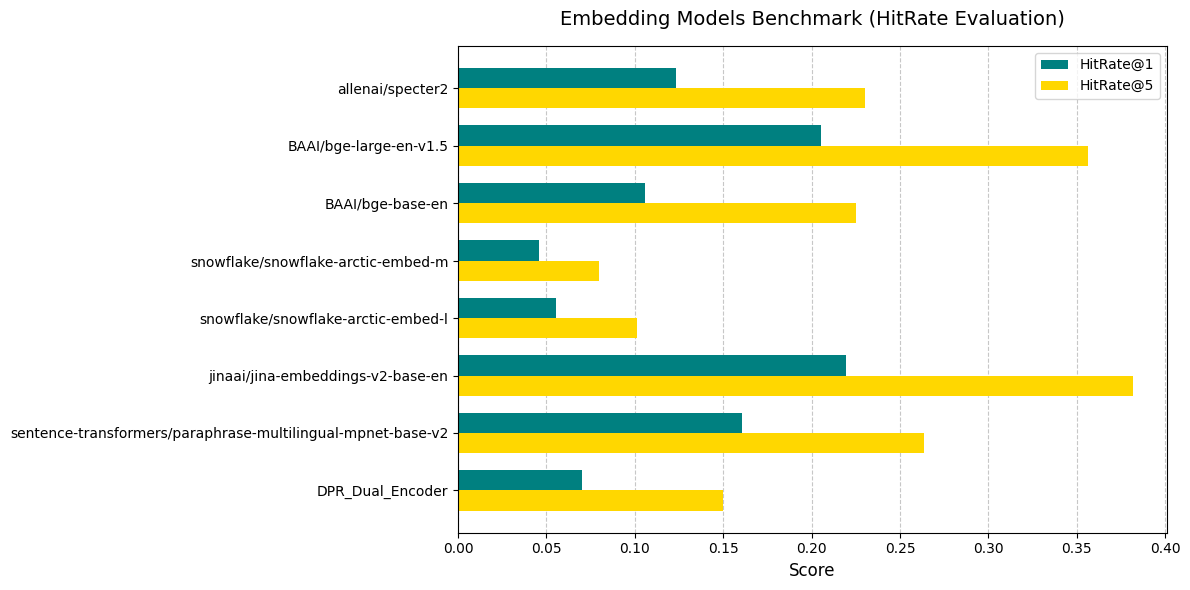

In [52]:
k1, k2 = 1, 5
models = fastembed_models  + ["DPR_Dual_Encoder"] 
group1 = [results[name][f"HitRate@{k1}"] for name in models]
group2 = [results[name][f"HitRate@{k2}"] for name in models]

y = np.arange(len(models))
height = 0.35  

fig, ax = plt.subplots(figsize=(12, 6)) 


rects1 = ax.barh(y - height/2, group1, height, label=f"HitRate@{k1}", color='teal')
rects2 = ax.barh(y + height/2, group2, height, label=f"HitRate@{k2}", color='gold')

ax.set_title('Embedding Models Benchmark (HitRate Evaluation)', fontsize=14, pad=15)
ax.set_xlabel('Score', fontsize=12)
ax.set_yticks(y)
ax.set_yticklabels(models)  

ax.invert_yaxis()

ax.legend()

ax.set_axisbelow(True)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()